In [2]:
# import Required liberies 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as pltb


In [2]:
# Laod the dataset
df = pd.read_csv("C:\\Users\\ssart\\Downloads\\Purchase_new.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ssart\\Downloads\\Purchase_new.csv'

In [22]:
df.head(10)

,Holiday,Discount,Free Delivery,Purchase
0,No,Yes,Yes,Yes
1,No,Yes,Yes,Yes
2,No,No,No,No
3,yes,Yes,Yes,Yes
4,yes,Yes,Yes,Yes
5,yes,No,No,No
6,yes,Yes,No,Yes
7,No,Yes,Yes,Yes
8,yes,Yes,Yes,Yes
9,yes,Yes,Yes,Yes


In [3]:
# Label encoding 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [33]:
# Apply label encoding to each categorical column
for column in df.columns:
    df[column] = le.fit_transform(df[column])


In [35]:
df.head()

,Holiday,Discount,Free Delivery,Purchase
0,0,1,1,1
1,0,1,1,1
2,0,0,0,0
3,1,1,1,1
4,1,1,1,1


In [36]:
#Divide the data into X amd Y variable
X = df.drop(columns={'Purchase'},axis=True)
y =df['Purchase']

In [37]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state = 42)

In [40]:
# Initialize the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()

In [41]:
# Train the model
model = DT.fit(X_train,y_train)

In [42]:
# Predict on the test set
y_pred = model.predict(X_test)

In [43]:
# Calculate accuracy
from sklearn.metrics import accuracy_score

In [51]:
#accuracy = accuracy_score(y_test)
accuracy = accuracy_score(y_test, y_pred)

In [52]:
print(accuracy)

1.0


In [4]:
from sklearn import tree

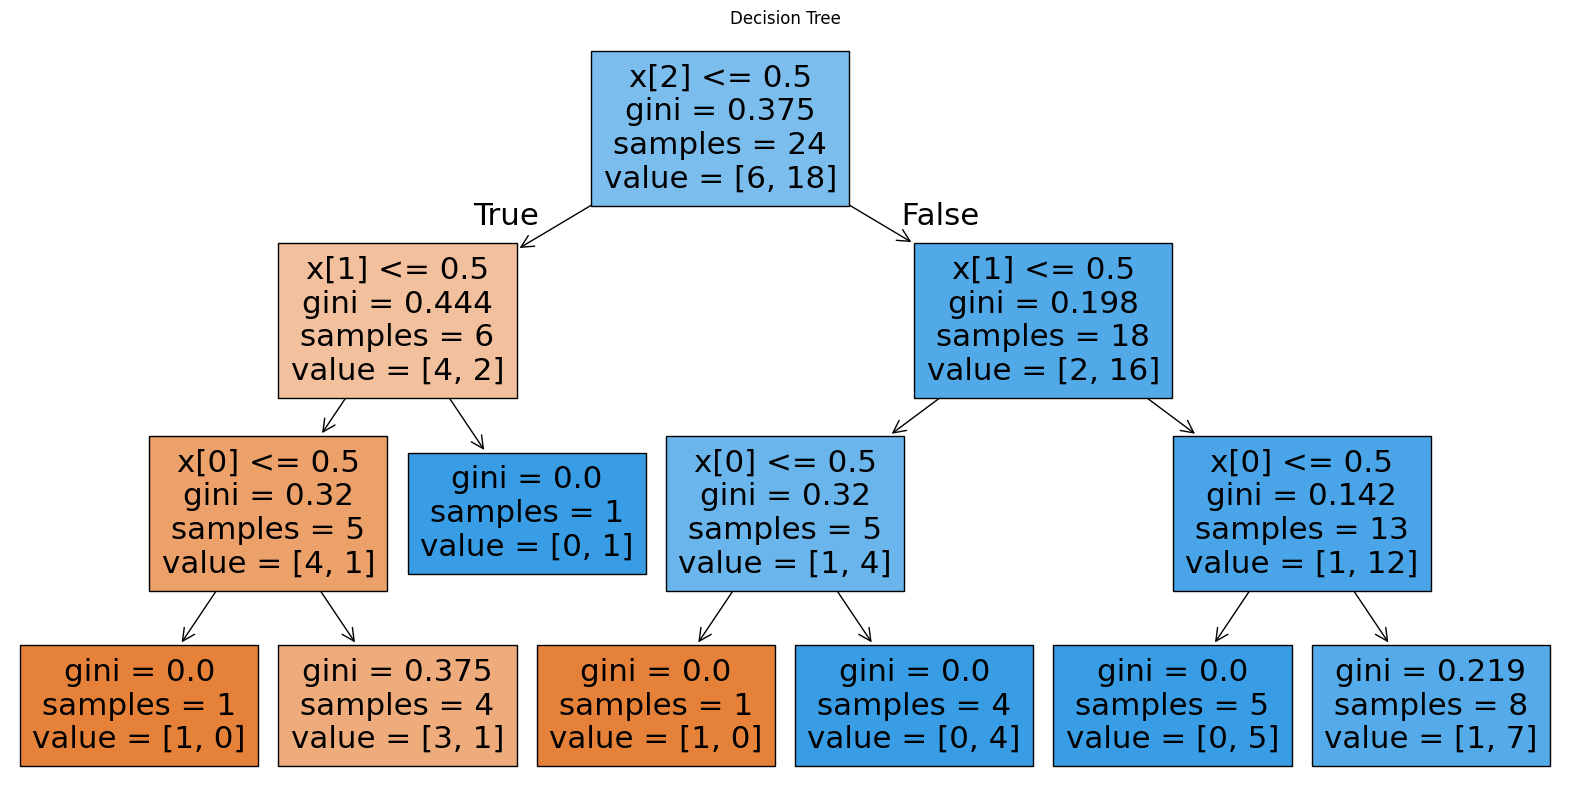

In [54]:
# Visualize the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True)
plt.title("Decision Tree")
plt.show()

In [55]:
class Node:
    def __init__(self, value):
        self.value = value
        self.next = None

def has_cycle(head):
    if head is None:
        return False
    
    slow = head
    fast = head

    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
        
        if slow == fast:
            return True
    
    return False

# Test cases
# Creating a list with no cycle: 1 -> 2 -> 3 -> 4
head1 = Node(1)
head1.next = Node(2)
head1.next.next = Node(3)
head1.next.next.next = Node(4)

# Creating a list with a cycle: 1 -> 2 -> 3 -> 4 -> 2 (cycle back to second node)
head2 = Node(1)
head2.next = Node(2)
head2.next.next = Node(3)
head2.next.next.next = Node(4)
head2.next.next.next.next = head2.next  # Creating a cycle

print(has_cycle(head1))  # Output: False
print(has_cycle(head2))  # Output: True


False
True


In [58]:
class Node:
    def __init__(self, value):
        self.value = value  # Value of the node
        self.left = None    # Left child
        self.right = None   # Right child

class BinaryTree:
    def __init__(self):
        self.root = None  # Root of the binary tree

    def insert(self, value):
        """Insert a node with the given value into the binary tree."""
        if not self.root:
            self.root = Node(value)  # If tree is empty, set root to new node
        else:
            self._insert(self.root, value)  # Otherwise, use helper method

    def _insert(self, current, value):
        """Helper method to insert a node into the binary tree."""
        if value < current.value:
            if current.left is None:
                current.left = Node(value)  # Insert as left child
            else:
                self._insert(current.left, value)  # Recurse to left subtree
        else:
            if current.right is None:
                current.right = Node(value)  # Insert as right child
            else:
                self._insert(current.right, value)  # Recurse to right subtree

    def delete(self, value):
        """Delete a node with the given value from the binary tree."""
        self.root = self._delete(self.root, value)

    def _delete(self, current, value):
        """Helper method to delete a node from the binary tree."""
        if not current:
            return current  # Node not found

        if value < current.value:
            current.left = self._delete(current.left, value)  # Recurse to left subtree
        elif value > current.value:
            current.right = self._delete(current.right, value)  # Recurse to right subtree
        else:
            # Node with only one child or no child
            if not current.left:
                return current.right
            elif not current.right:
                return current.left

            # Node with two children: get the inorder successor (smallest in the right subtree)
            temp = self._min_value_node(current.right)
            current.value = temp.value  # Copy the inorder successor's content to this node
            current.right = self._delete(current.right, temp.value)  # Delete the inorder successor

        return current

    def _min_value_node(self, node):
        """Helper method to find the node with the smallest value."""
        current = node
        while current.left:
            current = current.left  # Loop down to find the leftmost leaf
        return current

    def inorder_traversal(self):
        """Perform inorder traversal of the binary tree."""
        return self._inorder_traversal(self.root)

    def _inorder_traversal(self, node):
        """Helper method for inorder traversal."""
        res = []
        if node:
            res = self._inorder_traversal(node.left)  # Visit left subtree
            res.append(node.value)  # Visit node
            res = res + self._inorder_traversal(node.right)  # Visit right subtree
        return res

    def preorder_traversal(self):
        """Perform preorder traversal of the binary tree."""
        return self._preorder_traversal(self.root)

    def _preorder_traversal(self, node):
        """Helper method for preorder traversal."""
        res = []
        if node:
            res.append(node.value)  # Visit node
            res = res + self._preorder_traversal(node.left)  # Visit left subtree
            res = res + self._preorder_traversal(node.right)  # Visit right subtree
        return res

    def postorder_traversal(self):
        """Perform postorder traversal of the binary tree."""
        return self._postorder_traversal(self.root)

    def _postorder_traversal(self, node):
        """Helper method for postorder traversal."""
        res = []
        if node:
            res = self._postorder_traversal(node.left)  # Visit left subtree
            res = res + self._postorder_traversal(node.right)  # Visit right subtree
            res.append(node.value)  # Visit node
        return res

    def bfs(self):
        """Perform Breadth-First Search (BFS) traversal of the binary tree."""
        res = []
        if not self.root:
            return res
        queue = [self.root]  # Use a queue to help with BFS
        while queue:
            node = queue.pop(0)  # Dequeue a node
            res.append(node.value)
            if node.left:
                queue.append(node.left)  # Enqueue left child
            if node.right:
                queue.append(node.right)  # Enqueue right child
        return res

    def dfs(self):
        """Perform Depth-First Search (DFS) traversal of the binary tree."""
        return self._dfs(self.root)

    def _dfs(self, node):
        """Helper method for DFS traversal."""
        res = []
        if node:
            res.append(node.value)  # Visit node
            res = res + self._dfs(node.left)  # Visit left subtree
            res = res + self._dfs(node.right)  # Visit right subtree
        return res

# Usage example:
# Create a new BinaryTree
bt = BinaryTree()

# Insert nodes
bt.insert(5)
bt.insert(3)
bt.insert(7)
bt.insert(2)
bt.insert(4)
bt.insert(6)
bt.insert(8)

# Display the traversals
print("Inorder Traversal:", bt.inorder_traversal())
print("Preorder Traversal:", bt.preorder_traversal())
print("Postorder Traversal:", bt.postorder_traversal())
print("BFS Traversal:", bt.bfs())
print("DFS Traversal:", bt.dfs())

# Delete a node
bt.delete(3)
print("Inorder Traversal after deleting 3:", bt.inorder_traversal())


Inorder Traversal: [2, 3, 4, 5, 6, 7, 8]
Preorder Traversal: [5, 3, 2, 4, 7, 6, 8]
Postorder Traversal: [2, 4, 3, 6, 8, 7, 5]
BFS Traversal: [5, 3, 7, 2, 4, 6, 8]
DFS Traversal: [5, 3, 2, 4, 7, 6, 8]
Inorder Traversal after deleting 3: [2, 4, 5, 6, 7, 8]
